In [4]:
# Loading the required datasets 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Importing the datasest

In [5]:
M_food_prices = pd.read_csv("wfp_market_food_prices.csv", on_bad_lines='error')

In [6]:
M_food_prices.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,612035.000000,612035.000000,612035.000000,612035.000000,612035.000000,612034.000000,612034.000000,612034.000000,612034.000000,6.120340e+05
mean,142.686428,11254.992749,849.863812,158.700132,54.460397,14.927718,9.690055,6.396525,2012.312955,3.811781e+03
std,56.403162,18634.362224,494.039910,119.280848,21.693574,0.286900,11.197979,3.436530,3.677556,5.999491e+04
min,1.000000,0.000000,101.000000,50.000000,23.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,108.000000,1497.000000,422.000000,67.000000,28.000000,15.000000,5.000000,3.000000,2011.000000,5.778000e+01
50%,152.000000,1934.000000,892.000000,101.000000,61.000000,15.000000,5.000000,6.000000,2013.000000,2.060000e+02
75%,196.000000,21969.000000,1087.000000,227.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,6.000000e+02
max,238.000000,112869.000000,2094.000000,490.000000,95.000000,18.000000,97.000000,12.000000,2017.000000,5.833333e+06


In [7]:
# Changing the column name to something more meaningful

M_food_prices.rename(columns={
    'adm0_id': 'country_id',
    'adm0_name': 'country_name',
    'adm1_id': 'region_id',
    'adm1_name': 'region_name',
    'mkt_id': 'market_id',
    'cm_id': 'commodity_id',
    'cur_id': 'currency_id',
    'pt_id': 'price_type_id',
    'um_id': 'unit_measure_id',
    'mp_month': 'price_month',
    'mp_year': 'price_year',
    'mp_price': 'price'
}, inplace=True)



## Filtering Dataset for my data

In [8]:
M_food_prices = M_food_prices[M_food_prices['country_name'].isin(['India', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bhutan', 'Bangladesh'])]
M_food_prices.sample(20)

,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
216374,115,India,1505,Punjab,973,Bathinda,61,Lentils (masur),68,INR,15.0,Retail,5.0,KG,6.0,2013.0,55.29,"M/o Consumer Affairs, Food and Public Distribu..."
170228,115,India,1508,Tamil Nadu,931,Chennai,97,Sugar,68,INR,15.0,Retail,5.0,KG,9.0,2013.0,34.00,"M/o Consumer Affairs, Food and Public Distribu..."
395100,175,Nepal,2153,Eastern,663,Morang,52,Rice,62,NPR,15.0,Retail,5.0,KG,11.0,2009.0,26.00,"ABPMDD, MoAD"
189009,115,India,1510,Uttar Pradesh,947,Kanpur,61,Lentils (masur),68,INR,15.0,Retail,5.0,KG,2.0,2015.0,81.26,"M/o Consumer Affairs, Food and Public Distribu..."
210166,115,India,1511,West Bengal,964,Siliguri,173,Onions,68,INR,15.0,Retail,5.0,KG,3.0,2015.0,30.00,"M/o Consumer Affairs, Food and Public Distribu..."
208169,115,India,1493,Himachal Pradesh,963,Shimla,52,Rice,68,INR,15.0,Retail,5.0,KG,8.0,1997.0,12.00,"M/o Consumer Affairs, Food and Public Distribu..."
176861,115,India,1503,Nagaland,936,Dimapur,463,Milk (pasteurized),68,INR,15.0,Retail,15.0,L,9.0,2016.0,50.00,"M/o Consumer Affairs, Food and Public Distribu..."
162966,115,India,1494,Karnataka,926,Bengaluru,97,Sugar,68,INR,15.0,Retail,5.0,KG,10.0,2013.0,34.00,"M/o Consumer Affairs, Food and Public Distribu..."
202713,115,India,1498,Maharashtra,958,Raipur,173,Onions,68,INR,15.0,Retail,5.0,KG,7.0,2015.0,24.57,"M/o Consumer Affairs, Food and Public Distribu..."
445015,188,Pakistan,2277,Sindh,293,Karachi,284,Fuel (diesel),45,PKR,15.0,Retail,15.0,L,3.0,2016.0,71.34,Pakistan Bureau of Statics


## Identifying any missing values in the data set

In [9]:

missing_values = M_food_prices.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 country_id               0
country_name             0
region_id                0
region_name           2716
market_id                0
mkt_name                 0
commodity_id             0
cm_name                  0
currency_id              0
cur_name                 0
price_type_id            0
pt_name                  0
unit_measure_id          0
um_name                  0
price_month              0
price_year               0
price                    0
mp_commoditysource       0
dtype: int64


## Removing any duplicate entries in the data

In [10]:
M_food_prices_cleaned = M_food_prices.drop_duplicates()

## Summary of duplicate entries vs original data
No duplicate values were found in the dataset

In [11]:
print(len(M_food_prices_cleaned))
print(len(M_food_prices))
M_food_prices_cleaned.head(5)

83569
83569


,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
12663,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,12.0,2006.0,23.0,Website of Department of Agricultural Marketing
12664,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,1.0,2007.0,25.5,Website of Department of Agricultural Marketing
12665,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,2.0,2007.0,25.5,Website of Department of Agricultural Marketing
12666,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,3.0,2007.0,26.0,Website of Department of Agricultural Marketing
12667,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,4.0,2007.0,26.0,Website of Department of Agricultural Marketing


# Visualizations

Let us see how the prices for commodities are changing year over year across all the countries.

In [12]:
M_food_prices_cleaned['date'] = pd.to_datetime(M_food_prices_cleaned[['price_year', 'price_month']].rename(columns={'price_year': 'year', 'price_month': 'month'}).assign(day=1))

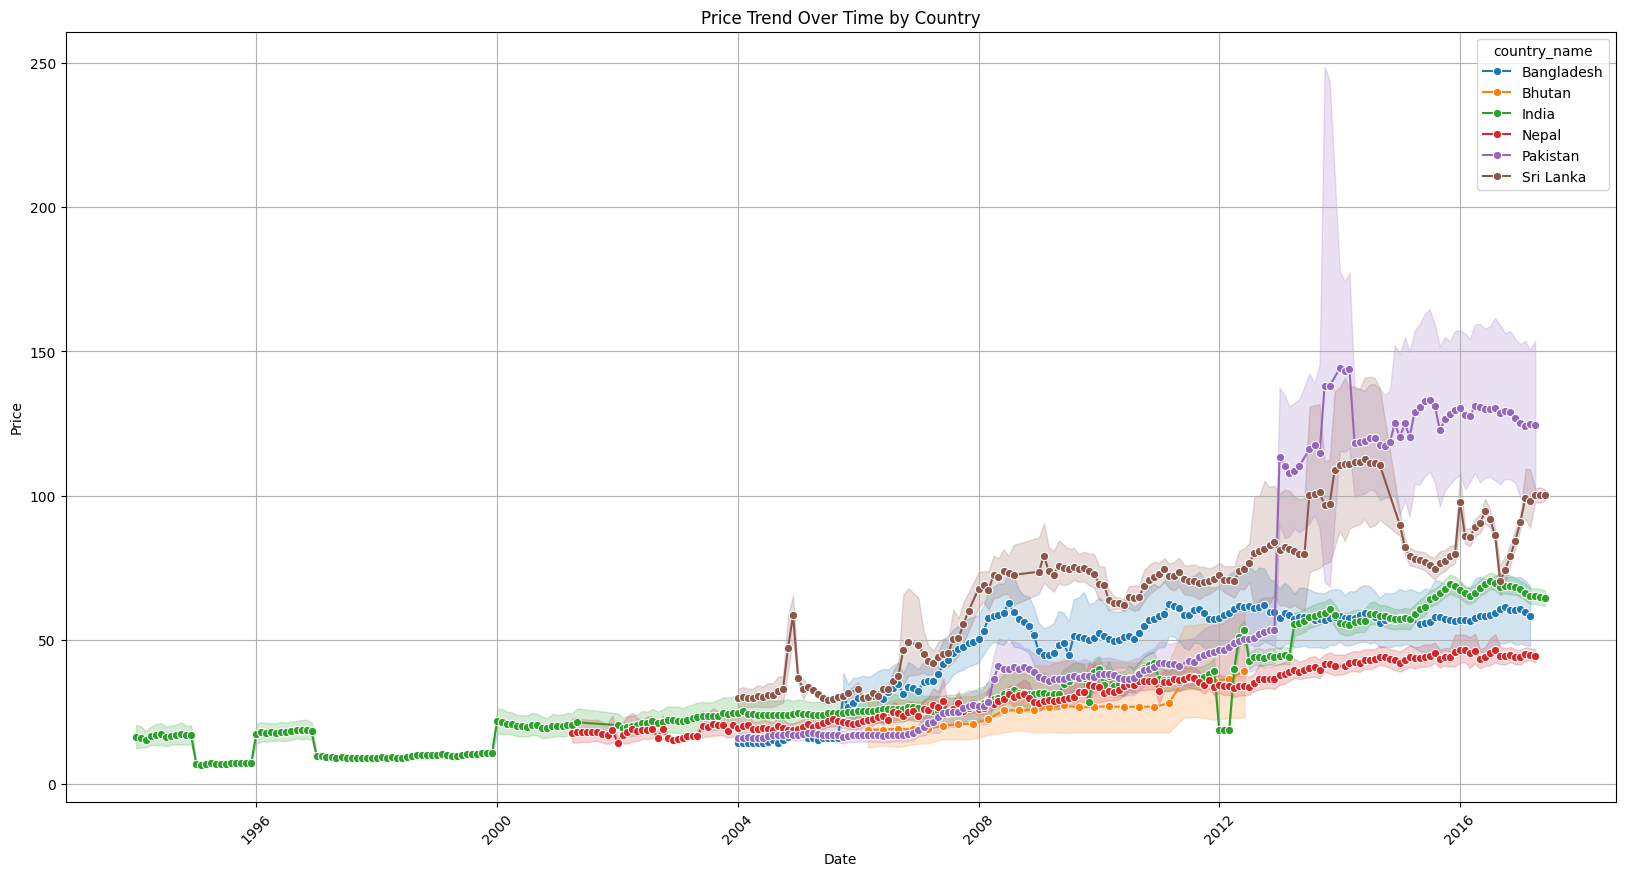

In [13]:
# Plot the data
plt.figure(figsize=(20,10))
sns.lineplot(data=M_food_prices_cleaned, x='date', y='price', hue='country_name', marker="o")

plt.title('Price Trend Over Time by Country')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Observations 

1. We can see that for most of the countries the price tracking started only after 2004. 
2. Pakistan saw a meteoric rise in prices compared to the other countries.
3. Since the prices are non-standard, this won't give us a clear picture of how they compare to each other


## Converting all the currency to USD from the native currency

Note: We are not accounting for the currency fluctuations over time and we take the latest currency values.

In [14]:
currency_conversion = {
    'BDT': 0.0091,   # Bangladeshi Taka to USD
    'BTN': 0.012,    # Bhutanese Ngultrum to USD (same as INR)
    'INR': 0.012,    # Indian Rupee to USD
    'NPR': 0.0075,   # Nepalese Rupee to USD
    'PKR': 0.0036,   # Pakistani Rupee to USD
    'LKR': 0.0031    # Sri Lankan Rupee to USD
}

In [15]:
# Function to convert prices to USD
def convert_to_usd(price, currency_code):
    if currency_code in currency_conversion:
        return price * currency_conversion[currency_code]
    else:
        return price  # If no conversion rate, leave the price unchanged

In [16]:
# Applying the conversion to the DataFrame
# Apply the conversion to the DataFrame
M_food_prices_cleaned['price_usd'] = M_food_prices_cleaned.apply(lambda row: convert_to_usd(row['price'], row['cur_name']), axis=1)

## Visualising the converted currency data

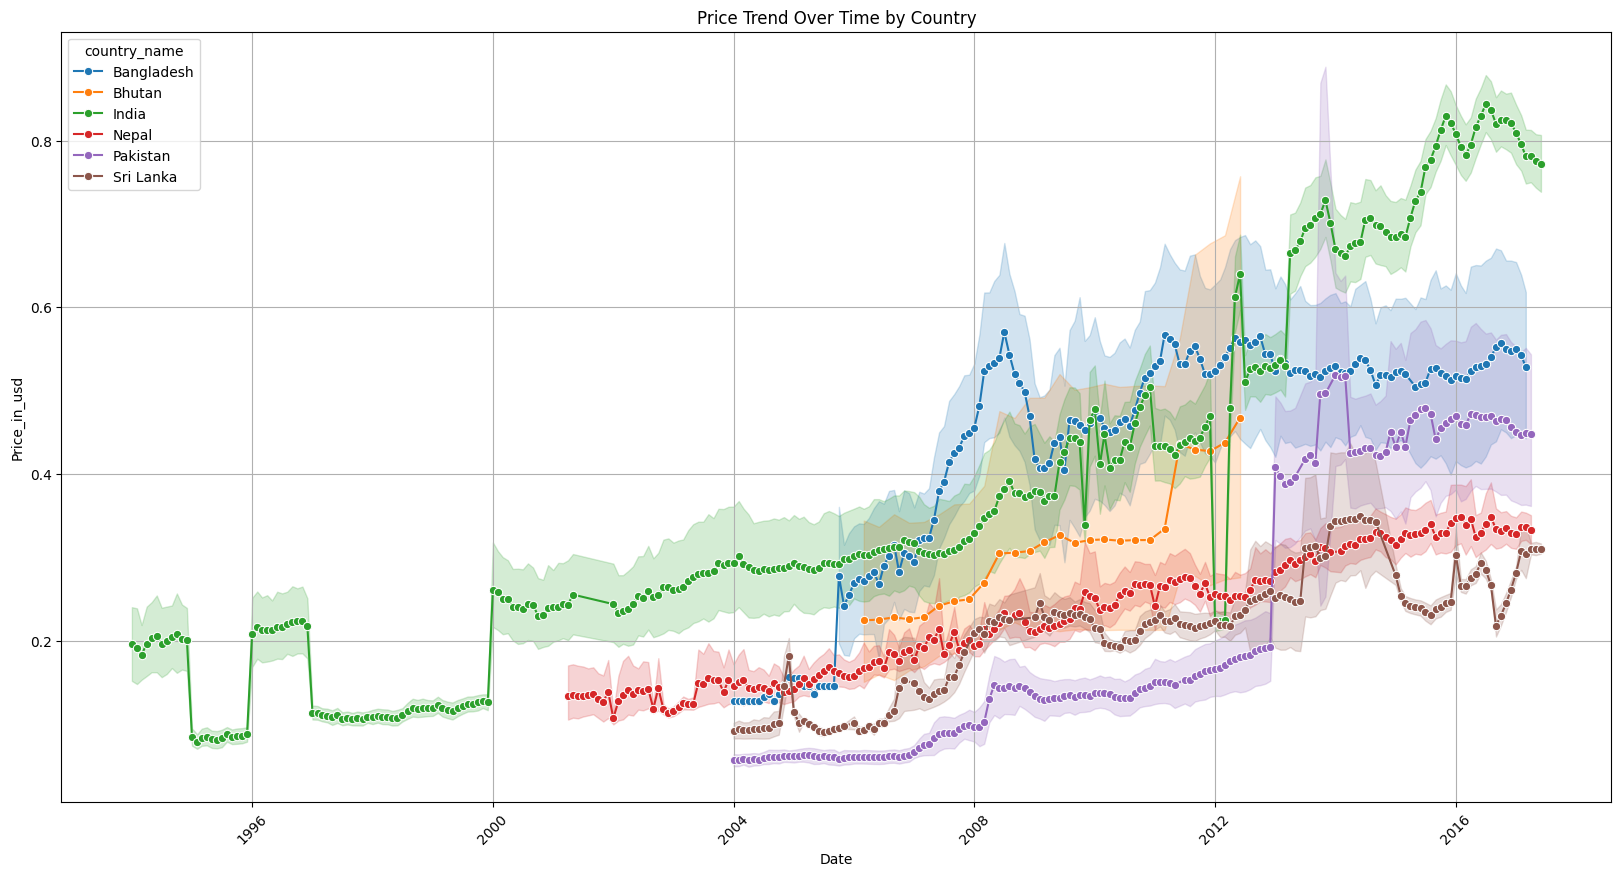

In [17]:
# Plot the data
plt.figure(figsize=(20,10))
sns.lineplot(data=M_food_prices_cleaned, x='date', y='price_usd', hue='country_name', marker="o")

plt.title('Price Trend Over Time by Country')
plt.xlabel('Date')
plt.ylabel('Price_in_usd')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observations

We can observe that after standardizing the prices to USD, there is no longer a country with a drastic increase in price, most countries exhibit similar trend where the prices are steadily increasing.

## Detect Outliers using box plots

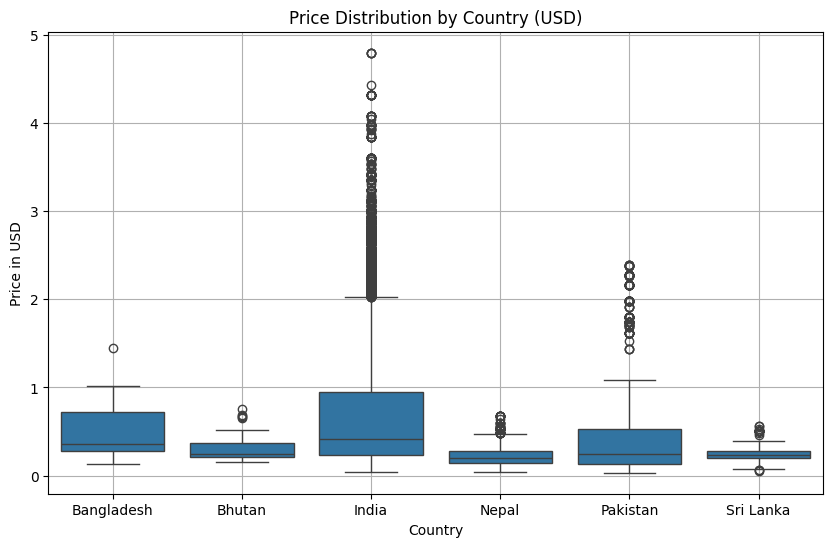

In [18]:
# Plot the boxplot to detect outliers
plt.figure(figsize=(10,6))
sns.boxplot(x='country_name', y='price_usd', data=M_food_prices_cleaned)

plt.title('Price Distribution by Country (USD)')
plt.xlabel('Country')
plt.ylabel('Price in USD')
plt.grid(True)
plt.show()

## Observations
We can see that there are many outliers in Country "India".

Pearson correlation coefficient: 0.3243385693983052
P-value: 0.0


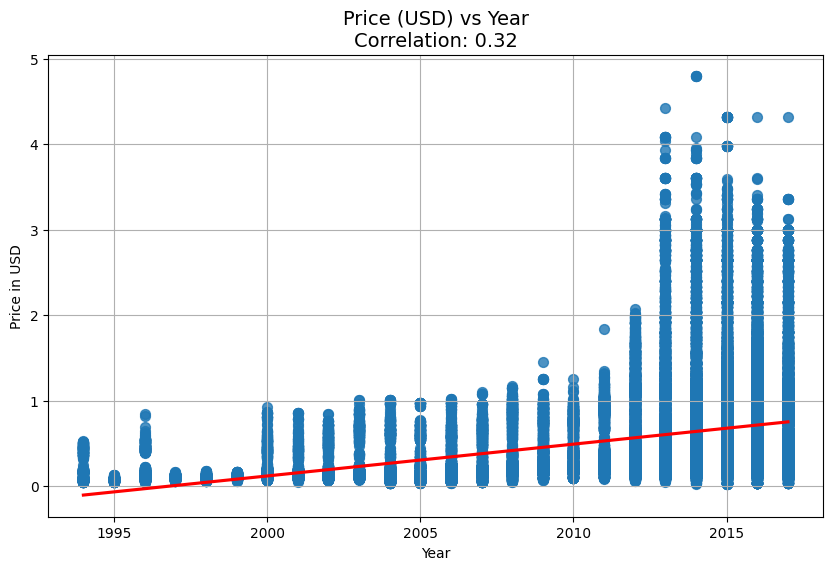

In [19]:
# Calculate Pearson correlation coefficient between price_year and price_usd
correlation, p_value = pearsonr(M_food_prices_cleaned['price_year'], M_food_prices_cleaned['price_usd'])
print(f"Pearson correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

# Scatter plot with a regression line to show the relationship between year and price
plt.figure(figsize=(10,6))
sns.regplot(x='price_year', y='price_usd', data=M_food_prices_cleaned, scatter_kws={'s':50}, line_kws={'color':'red'})

# Customize the plot
plt.title(f'Price (USD) vs Year\nCorrelation: {correlation:.2f}', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.grid(True)
plt.show()

# Observations 

We see that there is a medium strong correlation between the price and the year.

## Checking retail vs wholesale data

In [20]:
# Separate retail and wholesale data
retail_data = M_food_prices_cleaned[M_food_prices_cleaned['pt_name'] == 'Retail']
wholesale_data = M_food_prices_cleaned[M_food_prices_cleaned['pt_name'] == 'Wholesale']


### Calculating average prices

In [21]:
# Calculate the average retail and wholesale prices by commodity
avg_retail_prices = retail_data.groupby('cm_name')['price_usd'].mean().reset_index()
avg_wholesale_prices = wholesale_data.groupby('cm_name')['price_usd'].mean().reset_index()

# Merge retail and wholesale average prices into a single DataFrame
price_comparison = avg_retail_prices.merge(avg_wholesale_prices, on='cm_name', suffixes=('_retail', '_wholesale'))


Checking for one particular staple commodity like Wheat and plotting the price over time

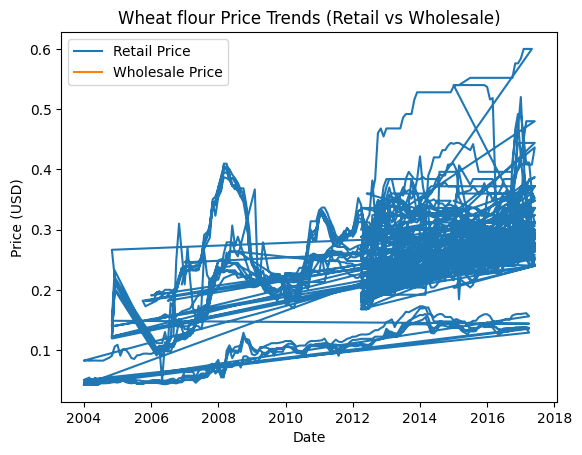

In [22]:
# Filter data for a specific commodity
commodity = 'Wheat flour'
retail_commodity = retail_data[retail_data['cm_name'] == commodity]
wholesale_commodity = wholesale_data[wholesale_data['cm_name'] == commodity]

# Plotting price trends over time
plt.plot(retail_commodity['date'], retail_commodity['price_usd'], label='Retail Price')
plt.plot(wholesale_commodity['date'], wholesale_commodity['price_usd'], label='Wholesale Price')

plt.title(f'{commodity} Price Trends (Retail vs Wholesale)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

Checking for Rice which is a Staple of the region

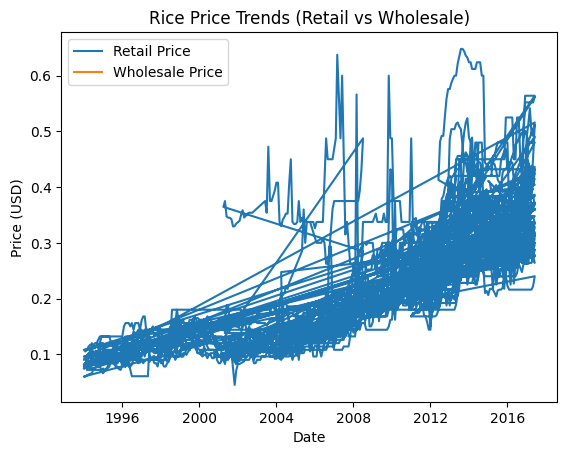

In [23]:

# Filter data for a specific commodity
commodity = 'Rice'
retail_commodity = retail_data[retail_data['cm_name'] == commodity]
wholesale_commodity = wholesale_data[wholesale_data['cm_name'] == commodity]

# Plotting price trends over time
plt.plot(retail_commodity['date'], retail_commodity['price_usd'], label='Retail Price')
plt.plot(wholesale_commodity['date'], wholesale_commodity['price_usd'], label='Wholesale Price')

plt.title(f'{commodity} Price Trends (Retail vs Wholesale)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Observations

There is no wholesale data for these commodities but we can see that the price is increasing over time.

### Region-wise price plot for India

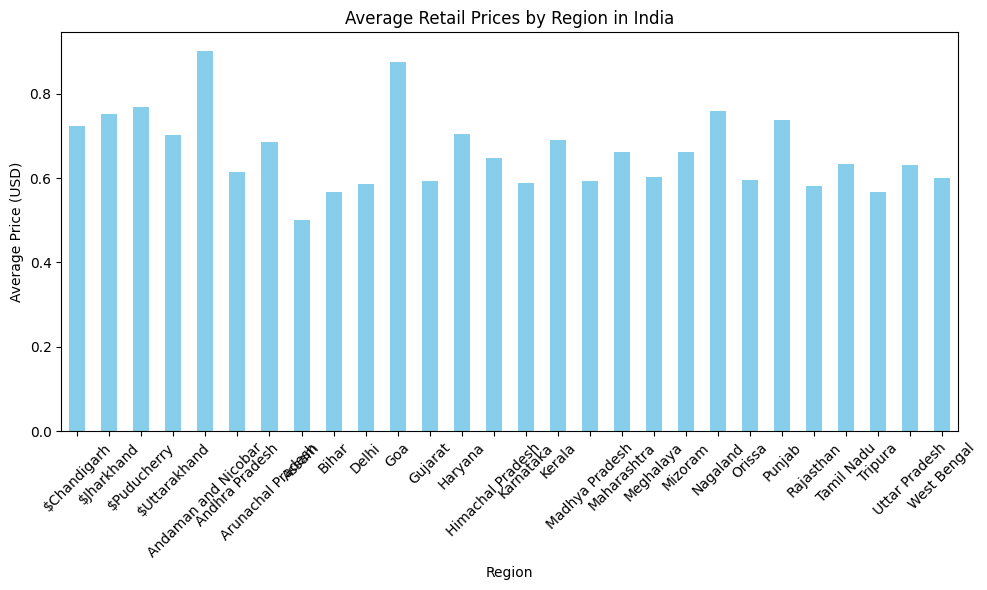

In [24]:
# Assuming M_food_prices_cleaned is your DataFrame and is already loaded

# Normalize pt_name column (if not already done)
M_food_prices_cleaned['pt_name'] = M_food_prices_cleaned['pt_name'].str.strip().str.lower()

# Filter the DataFrame for India
india_data = M_food_prices_cleaned[M_food_prices_cleaned['country_name'] == 'India']

# Separate retail data for India
retail_data = india_data[india_data['pt_name'] == 'retail']

# Calculate the average retail prices by region for India
avg_retail_prices = retail_data.groupby('region_name')['price_usd'].mean().reset_index()

# Rename the column for clarity
avg_retail_prices.rename(columns={'price_usd': 'avg_price_retail'}, inplace=True)

# Plotting the average retail prices by region in India
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot for average retail prices by region
avg_retail_prices.set_index('region_name')['avg_price_retail'].plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Average Retail Prices by Region in India')
ax.set_ylabel('Average Price (USD)')
ax.set_xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let us explore unique values and see if we can consolidate anywhere.

In [25]:
# # Printing unique values for each column
print("Unique values for locality_name:", M_food_prices_cleaned['region_name'].unique())
print("Unique values for mkt_name:", M_food_prices_cleaned['mkt_name'].unique())
print("Unique values for cm_name:", M_food_prices_cleaned['cm_name'].unique())
print("Unique values for um_name:", M_food_prices_cleaned['um_name'].unique())
print("Unique values for mp_commoditysource:", M_food_prices_cleaned['mp_commoditysource'].unique())


Unique values for locality_name: ['Barisal' 'Chittagong' 'Dhaka' 'Khulna' 'Rajshahi' 'Sylhet' nan 'Tripura'
 'Uttar Pradesh' 'Gujarat' 'Mizoram' 'Punjab' 'Karnataka' 'Bihar'
 'Madhya Pradesh' 'Orissa' '$Chandigarh' 'Tamil Nadu' '$Uttarakhand'
 'Delhi' 'Nagaland' 'Kerala' 'Assam' 'Haryana' 'Andhra Pradesh'
 'Arunachal Pradesh' 'Rajasthan' 'West Bengal' 'Himachal Pradesh'
 'Maharashtra' '$Jharkhand' 'Meghalaya' 'Andaman and Nicobar' 'Goa'
 '$Puducherry' 'Far Western' 'Eastern' 'Mid Western' 'Western' 'Central'
 'Sindh' 'North-West Frontier' 'Balochistan' 'Northern' 'North Central'
 'Uva' 'Southern' 'Sabaragamuwa' 'North Western']
Unique values for mkt_name: ['Barisal Division' 'Chittagong Division' 'Dhaka Division'
 'Khulna Division' 'Rajshahi Division' 'Sylhet Division'
 'National Average' 'Agartala' 'Agra' 'Ahmedabad' 'Aizwal' 'Amritsar'
 'Bengaluru' 'Bhagalpur' 'Bhopal' 'Bhubaneshwar' 'Chandigarh' 'Chennai'
 'Cuttack' 'Dehradun' 'Delhi' 'Dharwad' 'Dimapur' 'Dindigul' 'Ernakulam'
 'Guw

## Exploring wholesale data

In [26]:
# Check unique price types
unique_price_types = M_food_prices['price_type_id'].unique()
print(unique_price_types)


[15.]


We could see that there is no wholesale data for our countries

## Focusing on essential commodities

In [27]:
unique_commodity_names = M_food_prices['cm_name'].unique()
print(unique_commodity_names)

['Wheat flour' 'Rice (coarse)' 'Lentils (masur)' 'Oil (palm)'
 'Rice (local)' 'Rice (imported, Indian)' 'Rice' 'Potatoes' 'Sugar'
 'Lentils' 'Tomatoes' 'Onions' 'Tea (black)' 'Oil (mustard)'
 'Oil (soybean)' 'Lentils (moong)' 'Sugar (jaggery/gur)' 'Lentils (urad)'
 'Ghee (vanaspati)' 'Salt (iodised)' 'Milk (pasteurized)' 'Wheat'
 'Oil (sunflower)' 'Oil (groundnut)' 'Milk' 'Oil (cooking)' 'Eggs'
 'Ghee (artificial)' 'Rice (basmati, broken)' 'Poultry' 'Salt'
 'Fuel (diesel)' 'Fuel (petrol-gasoline)' 'Beans(mash)'
 'Wage (non-qualified labour, non-agricultural)' 'Rice (red nadu)'
 'Rice (long grain)']


## Consolidating the commodities

In [28]:
# Define a dictionary to map commodities to essential categories
commodity_mapping = {
    'Wheat': 'Grains and Cereals',
    'Wheat flour': 'Grains and Cereals',
    'Rice (coarse)': 'Grains and Cereals',
    'Rice (local)': 'Grains and Cereals',
    'Rice (imported, Indian)': 'Grains and Cereals',
    'Rice (basmati, broken)': 'Grains and Cereals',
    'Rice (red nadu)': 'Grains and Cereals',
    'Rice (long grain)': 'Grains and Cereals',
    'Lentils (masur)': 'Pulses and Lentils',
    'Lentils (moong)': 'Pulses and Lentils',
    'Lentils (urad)': 'Pulses and Lentils',
    'Beans(mash)': 'Pulses and Lentils',
    'Oil (palm)': 'Edible Oils',
    'Oil (mustard)': 'Edible Oils',
    'Oil (soybean)': 'Edible Oils',
    'Oil (sunflower)': 'Edible Oils',
    'Oil (groundnut)': 'Edible Oils',
    'Oil (cooking)': 'Edible Oils',
    'Potatoes': 'Vegetables',
    'Tomatoes': 'Vegetables',
    'Onions': 'Vegetables',
    'Sugar': 'Sweeteners',
    'Sugar (jaggery/gur)': 'Sweeteners',
    'Ghee (vanaspati)': 'Dairy Products',
    'Ghee (artificial)': 'Dairy Products',
    'Milk': 'Dairy Products',
    'Milk (pasteurized)': 'Dairy Products',
    'Eggs': 'Proteins',
    'Poultry': 'Proteins',
    'Salt': 'Salt',
    'Salt (iodised)': 'Salt',
    'Fuel (diesel)': 'Fuel',
    'Fuel (petrol-gasoline)': 'Fuel',
    'Tea (black)': 'Miscellaneous',
    'Wage (non-qualified labour, non-agricultural)': 'Miscellaneous'
}

# Apply the mapping to create a new 'commodity_category' column
M_food_prices['commodity_category'] = M_food_prices['cm_name'].map(commodity_mapping)


### Visualising the essential commodity prices

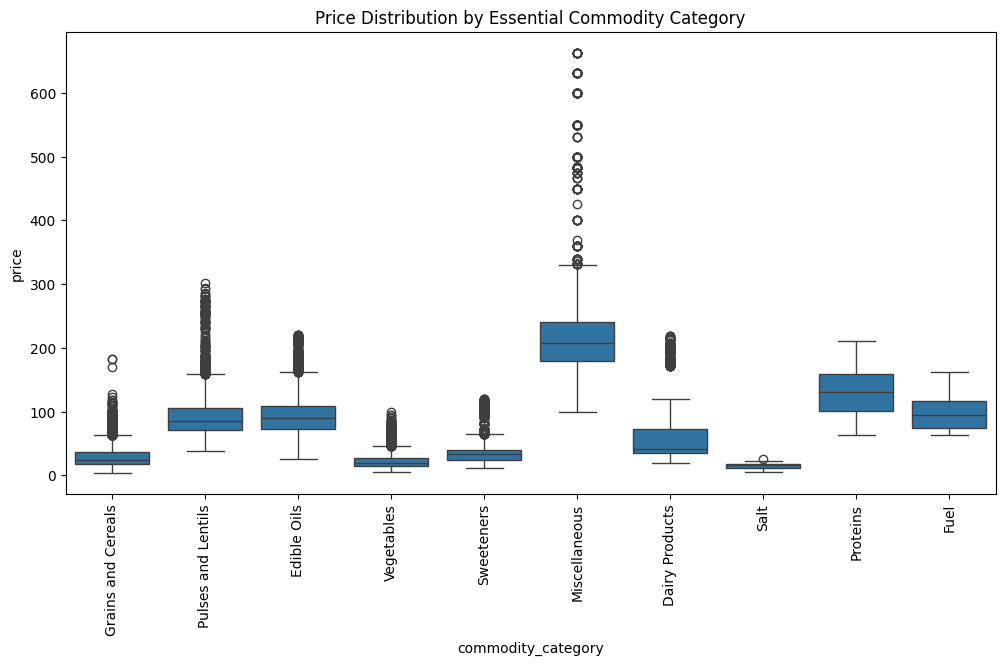

In [29]:
# Create a boxplot to show price distribution by commodity category
plt.figure(figsize=(12, 6))
sns.boxplot(x='commodity_category', y='price', data=M_food_prices)
plt.xticks(rotation=90)
plt.title('Price Distribution by Essential Commodity Category')
plt.show()

### Analyzing this trend over time 

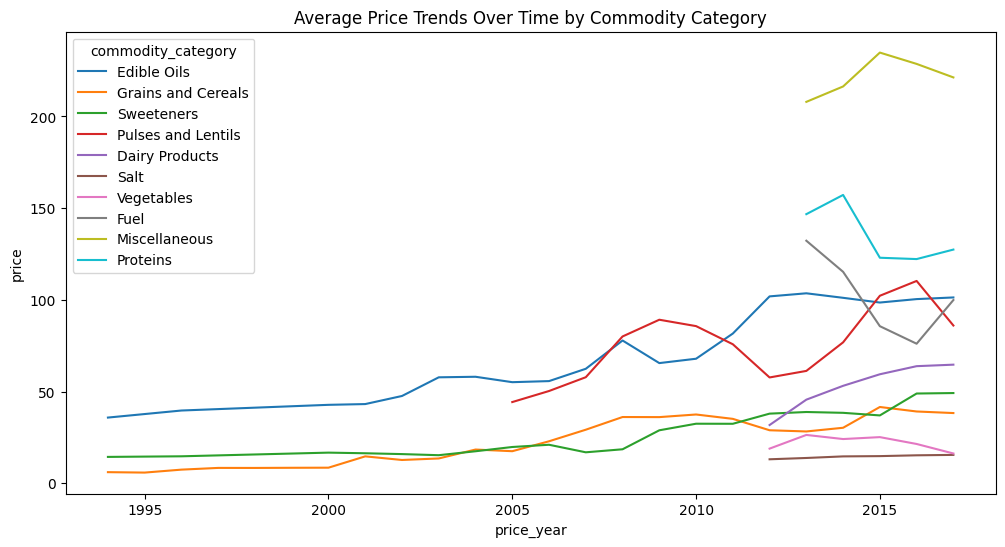

In [30]:
# Group by year and commodity category to calculate average price
price_trends = M_food_prices.groupby(['price_year', 'commodity_category'])['price'].mean().reset_index()

# Plot the price trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='price_year', y='price', hue='commodity_category', data=price_trends)
plt.title('Average Price Trends Over Time by Commodity Category')
plt.show()


### Comparing the prices across countries

In [31]:
# Group by country and commodity category to calculate min, max, and average prices
country_price_ranges = M_food_prices.groupby(['country_name', 'commodity_category']).agg({
    'price': ['min', 'max', 'mean']
}).reset_index()
print(country_price_ranges)


   country_name  commodity_category     price                      
                                          min       max        mean
0    Bangladesh         Edible Oils   34.0000  109.5000   76.435966
1    Bangladesh  Grains and Cereals   14.0000   45.0000   29.716016
2    Bangladesh  Pulses and Lentils   43.0000  159.2500   81.782302
3        Bhutan  Grains and Cereals   12.5500   63.1000   26.141731
4         India      Dairy Products   20.0000  120.0000   49.144562
5         India         Edible Oils   25.0000  192.0000   91.463989
6         India  Grains and Cereals    3.8000   50.0000   18.991720
7         India       Miscellaneous  100.0000  400.0000  204.481667
8         India  Pulses and Lentils   37.5000  195.0000   88.247900
9         India                Salt    5.0000   26.0000   14.746144
10        India          Sweeteners   10.8000   70.0000   31.856226
11        India          Vegetables    4.5700  100.0000   22.752876
12        Nepal  Grains and Cereals   11.0000   

In [39]:
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

features = ['country_id', 'region_id', 'market_id', 'commodity_id', 'unit_measure_id', 'price_month', 'price_year', 'commodity_category']
target = 'price'


# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(), ['country_id', 'region_id', 'market_id', 'commodity_id', 'commodity_category']),
    ('num', StandardScaler(), ['price_month', 'price_year'])
])


# Polynomial degree (adjust this as needed)
poly = PolynomialFeatures(degree=2)

# Create a pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', poly),
    ('regressor', LinearRegression())
])


# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(M_food_prices[features], M_food_prices[target], test_size=0.2, random_state=42)

# Fit the model
pipeline.fit(X_train, y_train)

# Predict prices on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model (example: mean squared error, R-squared score)
from sklearn.metrics import r2_score

mse = (y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Squared Error: (605672     65.00
189115      7.00
221264     30.00
192769     22.00
195342     48.00
           ...  
197224     70.00
392100     45.00
208993    160.00
186193     49.00
188303     10.89
Name: price, Length: 16714, dtype: float64, array([ 46.3741789 ,  13.79393162,  29.12199503, ..., 174.12680379,
        53.46192392,  28.94188532]))
R-squared Score: 0.9684200191120449


### Visualising the polynomial regression

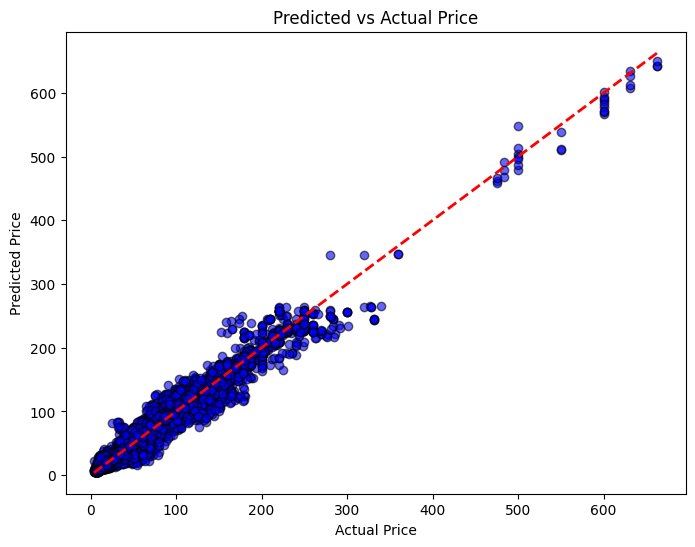

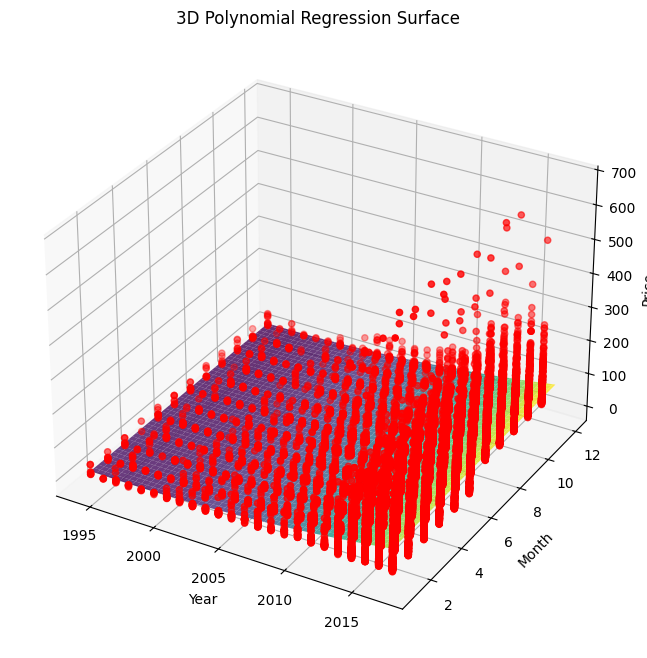

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming we have fitted the model as shown before

# 1. Predicted vs Actual Price Plot
y_pred = pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price')
plt.show()

# 2. 3D Polynomial Surface Plot (if focusing on two features)
# Let's focus on 'price_year' and 'price_month' for 3D visualization

# Select two features for a simpler 3D plot
X_train_2d = X_train[['price_year', 'price_month']].values
X_test_2d = X_test[['price_year', 'price_month']].values

# Train a polynomial regression model on these two features
pipeline_2d = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('regressor', LinearRegression())
])

pipeline_2d.fit(X_train_2d, y_train)

# Generate a meshgrid for the 3D surface plot
x0_range = np.linspace(X_test_2d[:, 0].min(), X_test_2d[:, 0].max(), 100)
x1_range = np.linspace(X_test_2d[:, 1].min(), X_test_2d[:, 1].max(), 100)
X0, X1 = np.meshgrid(x0_range, x1_range)
X_grid = np.c_[X0.ravel(), X1.ravel()]

# Predict prices for the grid
y_grid_pred = pipeline_2d.predict(X_grid).reshape(X0.shape)

# Plotting in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X0, X1, y_grid_pred, cmap='viridis', alpha=0.8)

# Scatter actual test data points
ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], y_test, color='r', marker='o')

ax.set_xlabel('Year')
ax.set_ylabel('Month')
ax.set_zlabel('Price')
ax.set_title('3D Polynomial Regression Surface')
plt.show()